In [ ]:
# CELL 0
# THIS CELL IS FOR RMS CALCULATING

# THE OPERATIONOF CELL 1 IS BASED ON THIS CELL


import numpy as np
from scipy.signal import butter, filtfilt
import csv
import gc



# ----------------------------------------------------
# -------------- Essential inputs --------------------
# ----------------------------------------------------

Export_FolderName = 'ProcessingTest'   # This is the folder name that all outputs will go in

RMS_FileName = '20250907_0708B_C207D_S_185D_250907_141340.rhd'             # this file name used for getting RMA

# input the file names
filenames = ['20250907_0708B_C207D_S_185D_250907_141340.rhd', 
             '20250907_0708B_C207D_S_185D_250907_141440.rhd',
             '20250907_0708B_C207D_S_185D_250907_141540.rhd',
             '20250907_0708B_C207D_S_185D_250907_141640.rhd',
             '20250907_0708B_C207D_S_185D_250907_141740.rhd']

# ----------------------------------------------------





#-----------------------------------------------------
# --------------------settings -----------------------
# ----------------------------------------------------

# specify the time range to calculate RMS
RMS_Str_t = 0              # start time of the calculation
RMS_End_t = 10000          # end time of the calculation


# parameters for filtering. 
#NOTE: these numbers are the same as the following cells
order = 3                    # order of filter applied
low_cutoff = 250             # low cutoff
high_cutoff = 3000           # high cutoff

# ---------------------------------------------------
# ------------------end of settings -----------------
# ---------------------------------------------------



# After running this cell, you will get:
# rms_noise: a 1D array, stores the rms noise of each channel



# ---------read and connect recorded files of different time segments-------------------

# do different operation for .rhd input and .rhs input
if RMS_FileName.endswith('.rhd'):
    %run importrhdutilities.py

    # define function to read data
    def RMS_process_file(RMS_FileName):
        RMS_result, RMS_data_present = load_file(RMS_FileName)
        if RMS_data_present:
            RMS_t = RMS_result.get('t_amplifier', [])  #get time information, store in one column
            RMS_AmplifierData = RMS_result.get('amplifier_data', {})  #get voltage information
            freq_params = RMS_result.get('frequency_parameters', {})
            desired_lower_bw = freq_params.get('desired_lower_bandwidth', None)
            desired_upper_bw = freq_params.get('desired_upper_bandwidth', None)
            actual_lower_bw = freq_params.get('desired_lower_bandwidth', None)
            actual_upper_bw = freq_params.get('desired_upper_bandwidth', None)
            return RMS_t, RMS_AmplifierData, desired_lower_bw, desired_upper_bw, actual_lower_bw, actual_upper_bw
        else:
            return None, None, None, None, None

    RMS_t, RMS_AmplifierData, RMS_desired_lower_bw, RMS_desired_upper_bw, RMS_actual_lower_bw, RMS_actual_upper_bw = RMS_process_file(RMS_FileName)

if RMS_FileName.endswith('.rhs'):
    %run importrhsutilities.py

    # define function to read data
    def RMS_process_file(RMS_FileName):
        RMS_result, RMS_data_present = load_file(RMS_FileName)
        if RMS_data_present:
            RMS_t = RMS_result.get('t', [])  #get time information, store in one column
            RMS_AmplifierData = RMS_result.get('amplifier_data', {})  #get voltage information
            freq_params = RMS_result.get('frequency_parameters', {})
            desired_lower_bw = freq_params.get('desired_lower_bandwidth', None)
            desired_upper_bw = freq_params.get('desired_upper_bandwidth', None)
            actual_lower_bw = freq_params.get('desired_lower_bandwidth', None)
            actual_upper_bw = freq_params.get('desired_upper_bandwidth', None)
            return RMS_t, RMS_AmplifierData, desired_lower_bw, desired_upper_bw, actual_lower_bw, actual_upper_bw
        else:
            return None, None, None, None, None

    RMS_t, RMS_AmplifierData, RMS_desired_lower_bw, RMS_desired_upper_bw, RMS_actual_lower_bw, RMS_actual_upper_bw = RMS_process_file(RMS_FileName)

# --------------------------------- End of data read ----------------------------------------


# get basic recording parameters from the imported file
RMS_total_time = RMS_t[len(RMS_t)-1] - RMS_t[0]
RMS_total_channel, RMS_total_data_point = RMS_AmplifierData.shape
RMS_sampling_rate = int(round(RMS_total_data_point / RMS_total_time))  #calculate the sampling rate and find the nearest integer


# trim the data according to pre-specified time range, updated in v1.1
RMS_data_point_range_1 = int(max(0, RMS_Str_t) * RMS_sampling_rate)
RMS_data_point_range_2 = int(min(RMS_total_time, RMS_End_t) * RMS_sampling_rate)
RMS_t = RMS_t[RMS_data_point_range_1:RMS_data_point_range_2]         # updatethe time point list to the shorted version
RMS_t = RMS_t - RMS_t[0]                                         # set the start point to be time 0
RMS_AmplifierData = RMS_AmplifierData[:, RMS_data_point_range_1:RMS_data_point_range_2]   # same thing to amplifier data

rms_noise = np.empty(RMS_total_channel)  # used to store all noise levels


# define the setting for butterworth filtering
nyquist_freq = 0.5 * RMS_sampling_rate
low = low_cutoff / nyquist_freq
high = high_cutoff / nyquist_freq

# create a butterworth filter
b, a = butter(order, [low, high], btype='band')


for i in range(RMS_total_channel):
    processing_channel = RMS_AmplifierData[i]
    filtered_data = filtfilt(b, a, processing_channel)  #apply butter filter to channel
    rms_noise[i] = np.std(filtered_data) 

# Export this RMS result
# Check if the folder exists, otherwise, creat the folder for data exportation
if not os.path.exists(Export_FolderName):
    os.mkdir(Export_FolderName)       # generate a new folder to store all the outputs
    print(f"Folder '{Export_FolderName}' created\n\n")
else:
    print(f"Folder '{Export_FolderName}' already exists\n\n")    

    
print('sampling rate is %d' % RMS_sampling_rate)
print(f'desired/actual lower bandwidth: {RMS_desired_lower_bw} Hz, {RMS_actual_lower_bw} Hz')
print(f'desired/actual upper bandwidth: {RMS_desired_upper_bw} Hz, {RMS_actual_upper_bw} Hz')
print('\n\n')


# Define the file name
csv_filename = Export_FolderName + "/RMS_Noise_Level.csv"

# Define the header row
header_row = ['Channel']
header_row.append('RMS noise')

# Write data to CSV file
with open(csv_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)

    # Write the header row
    writer.writerow(header_row)

    # Write data rows
    for i in range(RMS_total_channel):
        row_data = [i]
        row_data.append(rms_noise[i])
        writer.writerow(row_data)

print(f"CSV file '{csv_filename}' has been created successfully.")


# store the filename information
import h5py
# Write to HDF5
with h5py.File(Export_FolderName + "/filenames.h5", 'w') as hdf:
    hdf.create_dataset('filenames', data=filenames, chunks=True, compression="gzip")

print('filenames.h5 created successfully!')

# store the rms_noise into HDF5
# Write to HDF5
with h5py.File(Export_FolderName + "/rms_noise.h5", 'w') as hdf:
    hdf.create_dataset('rms_noise', data=rms_noise, chunks=True, compression="gzip")

print('rms_noise.h5 created successfully!')



# clear the parameters of this cell
del RMS_Str_t
del RMS_End_t
del RMS_t
del RMS_AmplifierData
del RMS_total_time
del RMS_total_channel
del RMS_total_data_point
del RMS_sampling_rate
del RMS_desired_lower_bw
del RMS_desired_upper_bw
del RMS_actual_lower_bw
del RMS_actual_upper_bw
del RMS_data_point_range_1
del RMS_data_point_range_2
del nyquist_freq
del low
del high
del b
del a
del processing_channel
del filtered_data
del csv_filename
del header_row
del row_data
del writer
gc.collect()

print('\n   THIS CELL IS DONE !!!')


Reading Intan Technologies RHD Data File, Version 3.3

Found 240 amplifier channels.
Found 15 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.000 seconds of data.  Amplifiers were sampled at 20.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 3.9 seconds
Folder 'ProcessingTest' already exists


sampling rate is 20000
desired/actual lower bandwidth: 0.10000000149011612 Hz, 0.10000000149011612 Hz
desired/actual upper bandwidth: 3000.0 Hz, 3000.0 Hz



CSV file 'ProcessingTest/RMS_Noise_Level.csv' has been created successfully.
filenames.h5 created successfully!
rms_noise.h5 created successfully!

   THIS CELL IS DONE !!!


filenames loaded

Reading Intan Technologies RHD Data File, Version 3.3

Found 240 amplifier channels.
Found 15 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.000 seconds of data.  Amplifiers were sampled at 20.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 3.2 seconds

Reading Intan Technologies RHD Data File, Version 3.3

Found 240 amplifier channels.
Found 15 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.000 seconds of data.  Amplifiers were sampled a

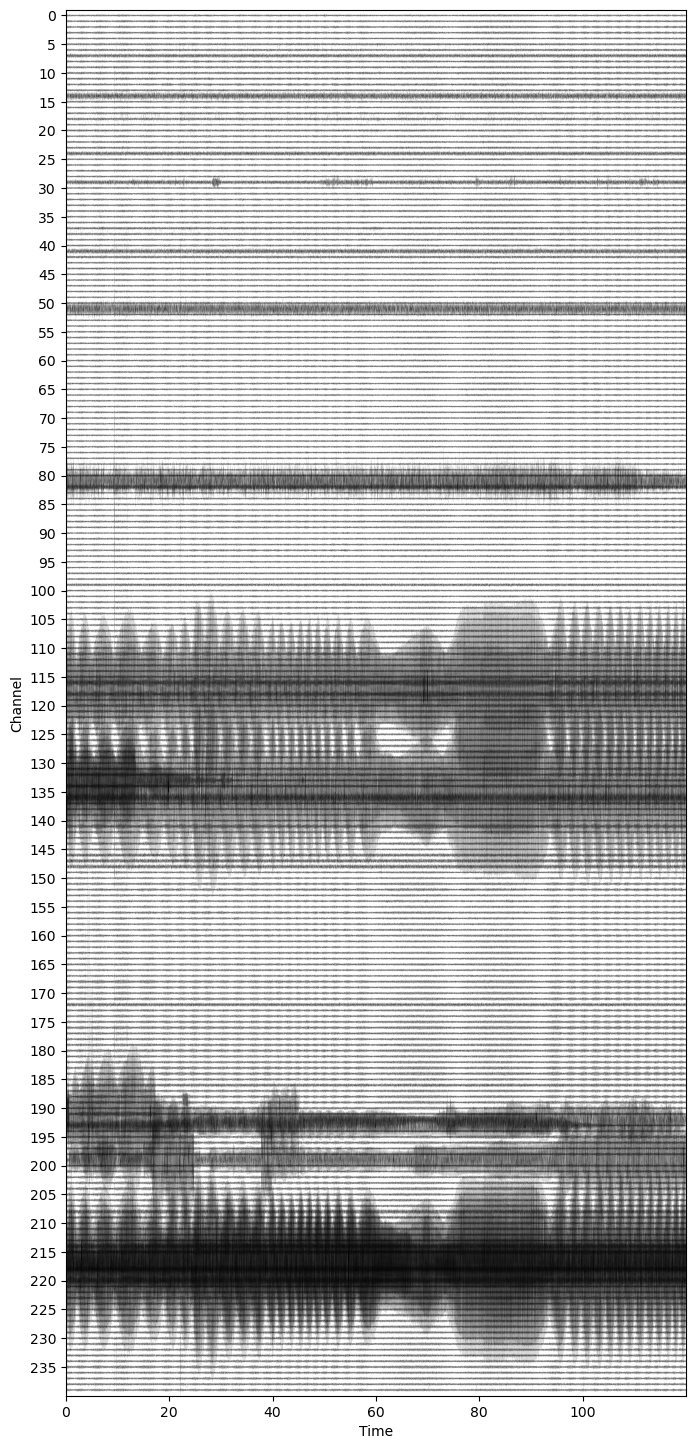


   THIS CELL IS DONE !!!


In [10]:

# ----------------------------------------------------------------
#      NOT A NECESSARY CELL --------------
# ----------------------------------------------------------------


import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import csv
import os
import gc

# ------------------------------------------------------------------------------
# ----------paratemers for data processing, make changes here-------------------
# ------------------------------------------------------------------------------

time_range_1 = 0
time_range_2 = 10000         # these two time points define the processing time range, updated in v1.1
                             # the defalt value for time_range_1 is 0, for time_range_2 is 10000

reduce_dp = 20               # plot only one datapoint within a series of them    

# ------------------------------------------------------------------------------
    
    
    
    
    
    

# ------------------------------------------------------------------------------
# -----------------------Do not change anything below---------------------------
# ------------------------------------------------------------------------------

# parameters for data processing
# parameters for filtering. 
#NOTE: these numbers are the same as the following cells
order = 3                    # order of filter applied
low_cutoff = 250             
high_cutoff = 3000           


# --------------------------------- Read filenames -------------------------------------

import h5py
# Read filenames
with h5py.File(Export_FolderName + "/filenames.h5", 'r') as hdf:
    filenames = hdf['filenames'][:]
    
# Decode the filenames from bytes to strings
filenames = [filename.decode('utf-8') for filename in filenames]

print('filenames loaded')




# ---------read and connect recorded files of different time segments-------------------

# do different operation for .rhd input and .rhs input
if filenames[0].endswith('.rhd'):
    %run importrhdutilities.py

    # define a function to read data
    def process_file(filename):
        result, data_present = load_file(filename)
        if data_present:
            t = result.get('t_amplifier', [])  #get time information, store in one column
            amplifier_data = result.get('amplifier_data', {})  #get voltage information
            return t, amplifier_data
        else:
            return None, None

# if inputs are .rhs
if filenames[0].endswith('.rhs'):
    %run importrhsutilities.py

    # define a function to read data
    def process_file(filename):
        result, data_present = load_file(filename)
        if data_present:
            t = result.get('t', [])  #get time information, store in one column
            amplifier_data = result.get('amplifier_data', {})  #get voltage information
            return t, amplifier_data
        else:
            return None, None

# ----------------------------------End of file reading ----------------------------------




all_results = []  # store all readed results
for filename in filenames:
    result = {}
    result['filename'] = filename
    result['t_amplifier'],result['amplifier_data'] = process_file(filename)
    all_results.append(result)
    
del result           # clear and release the data in result (v2.0)
gc.collect()

t = np.concatenate([result['t_amplifier'] for result in all_results])
amplifier_data = np.concatenate([result['amplifier_data'] for result in all_results], axis = 1) #stack amplifier data according to rows

del all_results       # clear and release the data in all_resultsc(v2.0)
gc.collect()

# get basic recording parameters from the imported file
total_time = t[len(t)-1]
total_channel, total_data_point = amplifier_data.shape
sampling_rate = int(round(total_data_point / total_time))  #calculate the sampling rate and find the nearest integer


# trim the data according to pre-specified time range, updated in v1.1
data_point_range_1 = int(max(0, time_range_1) * sampling_rate)
data_point_range_2 = int(min(total_time, time_range_2) * sampling_rate)
t = t[data_point_range_1:data_point_range_2]         # updatethe time point list to the shorted version
t = t - t[0]                                         # set the start point to be time 0
amplifier_data = amplifier_data[:, data_point_range_1:data_point_range_2]   # same thing to amplifier data

total_time = t[len(t)-1]
total_channel, total_data_point = amplifier_data.shape     # re-set the total time, channel number and so on, for the codes below





# -------------------visulize the file import and quick check-------------------------

print('\n\n\n')
print('total recording time = %f s' % total_time)
print('%d channels recorded in total' % total_channel)
print('%d data points for each channel' % total_data_point)
print('sampling rate is %d' % sampling_rate)
print('manually specify processing time range: between %d s and %d s\n\n\n' % (time_range_1, time_range_2))




# ---------------------------start of raw data filtering--------------------------

all_filtered_data = np.zeros((total_channel, total_data_point))  #used to store data after filtering

# 计算归一化的截止频率
nyquist_freq = 0.5 * sampling_rate
low = low_cutoff / nyquist_freq
high = high_cutoff / nyquist_freq

# 使用 Butterworth 滤波器设计滤波器系数
b, a = butter(order, [low, high], btype='band')

for i in range(total_channel):
    processing_channel = amplifier_data[i]
    filtered_data = filtfilt(b, a, processing_channel)  #apply butter filter to channel
    all_filtered_data[i,:] = filtered_data              #store the filtered data
    if (i+1) % 20 == 0:
        print('%d channels out of %d filtering done!' %((i+1), total_channel))
    
del processing_channel
del filtered_data
gc.collect()
    
print('Signal filtering finished!')

all_filtered_data_plot = np.zeros((total_channel, int(total_data_point/reduce_dp)))
t_plot = np.zeros(int(total_data_point/reduce_dp))

for j in range(int(total_data_point/reduce_dp)):
    t_plot[j] = t[j*reduce_dp]
    for i in range(total_channel):
        all_filtered_data_plot[i][j] = all_filtered_data[i][j*reduce_dp]
    
del amplifier_data
del all_filtered_data
gc.collect()

print('\n   DATA PROCESSING IS DONE !!!')




# --------------------------------------------------------------------------------------------
# ----------------------------------- for raw data viewing -----------------------------------
# --------------------------------------------------------------------------------------------


# ------------------------- Plot figures to quick check ---------------------

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Creating subplots with different heights
fig, ax = plt.subplots(1, 1,                                      # number of rows, numner of columns
                       figsize=(8, 18),                           # figure width, figure height
                      )
                              
y_stack = 30  # Vertical offset for stacking channels

for i in range(total_channel):  # Loop over each channel
    ax.plot(t_plot, all_filtered_data_plot[i,:]-i*y_stack,     # plot data
               color='black',                              # set colors
               linewidth=0.02                                 # width og plots
              )
    
ax.set_xlabel('Time')
ax.set_xlim(0,total_time)
ax.set_ylabel('Channel')
ax.set_ylim(-total_channel*y_stack,y_stack)
ax.set_yticks(np.arange(0, -total_channel*y_stack, step = -5*y_stack))     # set y-tick locations
ax.set_yticklabels(np.arange(0, total_channel, step = 5))   
ax.grid(False)                                             # Remove the solid grid lines

plt.show()

print('\n   THIS CELL IS DONE !!!')